In [1]:
# change to the root directory of the project
import os
if os.getcwd().split("/")[-1] == "examples":
    os.chdir('..')
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Let's import the fhn model
from neurolib.models.fhn import FHNModel
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

# Set plot and print options
plt.rcParams['axes.grid'] = True
# a nice color map
plt.rcParams['image.cmap'] = 'plasma'
plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['lines.linewidth'] = 0.8
np.set_printoptions(precision=3)

# define model parameters and external input such that we find bistability
# in the model above, no external input to x_2 is included

fhn = FHNModel()

epsilon = 8.0
external_input = [0.2, 0.0]

fhn.params['x_ext'] = np.array([external_input[0]])
fhn.params['y_ext'] = np.array([external_input[1]])
fhn.params['epsilon'] = epsilon

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def x1_nullcline(x_):
    return -fhn.params['alpha']*x_**3 + fhn.params['beta']*x_**2 +fhn.params['gamma']*x_ + fhn.params['x_ext']

def x2_nullcline(x_):
    return (x_ + fhn.params['y_ext']*fhn.params['tau'])/fhn.params['epsilon']

def fp_func(x_):
    return x2_nullcline(x_) - x1_nullcline(x_)

low_lim = -2.
up_lim = 2.
x = np.arange(low_lim,up_lim,0.01)

ic_bistability = [0.2, 0.4, 0.6]

# fixed points for default parameter choice
fixed_points_x = fsolve(fp_func, ic_bistability)
fixed_points = np.zeros([len(fixed_points_x), 2])
for i in range(len(fixed_points_x)):
    fixed_points[i,:] = [fixed_points_x[i], x1_nullcline(fixed_points_x[i])[0]]
print("Fixed points: ", np.around(fixed_points,3))

Fixed points:  [[0.235 0.029]
 [0.414 0.052]
 [0.684 0.085]]


In [34]:
# test example for stable fixed point with/ without *step_size_

c_mat = np.array([[0.]])
c_scheme = np.zeros((len(fhn.output_vars), len(fhn.output_vars) ))
c_scheme[0,0] = 1.

fhn = FHNModel()

u_mat = np.identity(fhn.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

epsilon = 8.0
external_input = [0.2, 0.0]
duration = 30

fhn.params['x_ext'] = np.array([external_input[0]])
fhn.params['y_ext'] = np.array([external_input[1]])
fhn.params['epsilon'] = epsilon
fhn.params['duration'] = duration

initial_state = [[0.2, 0.0], [0.4, 0.05], [0.7, 0.1]]

start_fixed_point = 0 # lower (0), unstable (1) or upper (2)
target_fixed_point = 2 # lower (0), unstable (1) or upper (2)
fhn.params['xs_init']= np.array([[initial_state[start_fixed_point][0]]])
fhn.params['ys_init']= np.array([[initial_state[start_fixed_point][1]]])
            
state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(round(fhn.params['duration']/fhn.params['dt'],1)+1)))
target_state = state.copy()

fhn.run()

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]
for i_time in range(int(round(fhn.params['duration']/fhn.params['dt'],1)+1)):
    target_state[:,0,i_time] = state[:,0,0] + ( fixed_points[target_fixed_point,0]
                                               - state[:,0,0] ) * i_time / (fhn.params['duration']/fhn.params['dt'])
    target_state[:,1,i_time] = state[:,1,0] + ( fixed_points[target_fixed_point,1]
                                               - state[:,1,0] ) * i_time / (fhn.params['duration']/fhn.params['dt'])

control0 = fhn.getZeroControl()
print("initial cost = ", fhn.costIntegral(fhn.cost(state, target_state, control0)) )

initial cost =  0.9325660886124562


RUN  0 , total integrated cost:  0.9325660886124562
RUN  1 , total integrated cost:  0.0014801938006712278
RUN  2 , total integrated cost:  0.0011314056514008324
Improved over  2  iterations by  100  percent.
cost_int:  [0.933 0.001 0.001]
runtime:  [0.001 0.281 0.53 ]


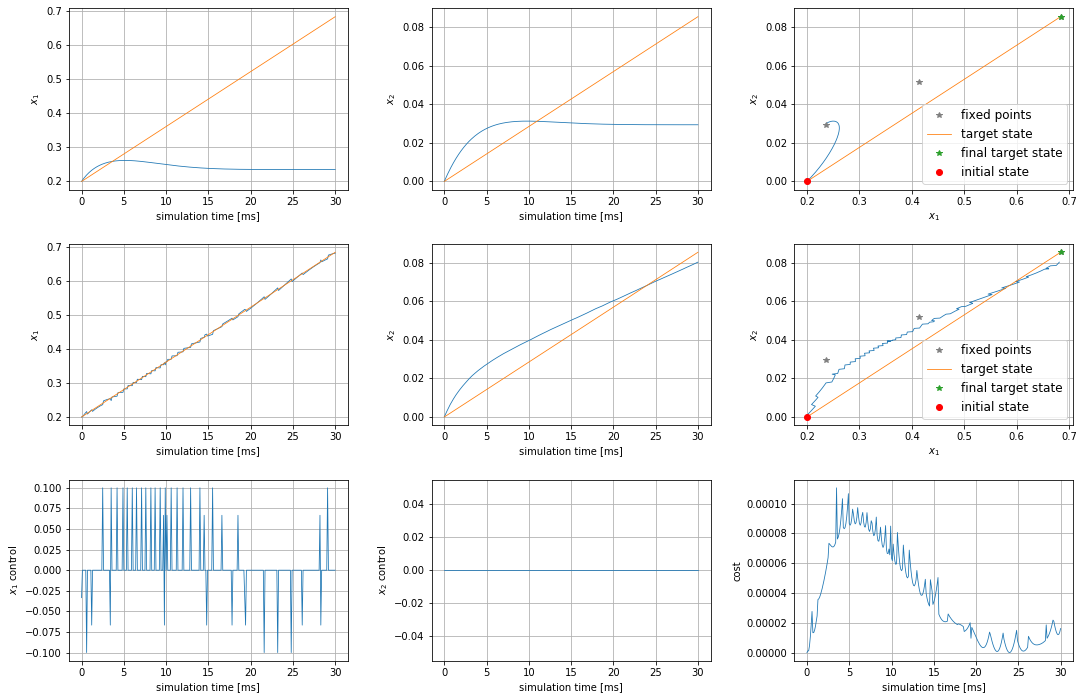

In [35]:
tolerance = 1e-6
inst_tolerance = 1e-6
stepSize = 0.1
incl_steps = 10
max_iteration = 2

opt, best, cost_int, runtime = fhn.getOptimalControl(control0, target_state, stepSize, max_iteration, tolerance, 
                    inst_tolerance, min(incl_steps, int(round(fhn.params['duration']/fhn.params['dt'],1)+1) ) )

fhn.run(control = best)

print("cost_int: ", cost_int)
print("runtime: ", runtime)
state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

plot_control(target_state, best, fhn.cost(state, target_state, best))

RUN  0 , total integrated cost =  0.9325660886124562
RUN  1 , total integrated cost =  0.49101316217331337
beta min, max =  1.0565005515712718 1.2883361237459647
RUN  2 , total integrated cost =  0.4241144155724879
beta min, max =  0.968752732691339 15.238080785698047
descent condition 1 not satisfied for time index  0
descent condition 1 not satisfied for time index  1
descent condition 1 not satisfied for time index  2
descent condition 1 not satisfied for time index  3
descent condition 1 not satisfied for time index  4
descent condition 1 not satisfied for time index  5
descent condition 1 not satisfied for time index  6
descent condition 1 not satisfied for time index  7
descent condition 1 not satisfied for time index  8
descent condition 1 not satisfied for time index  9
descent condition 1 not satisfied for time index  10
descent condition 1 not satisfied for time index  11
descent condition 1 not satisfied for time index  12
descent condition 1 not satisfied for time index  13

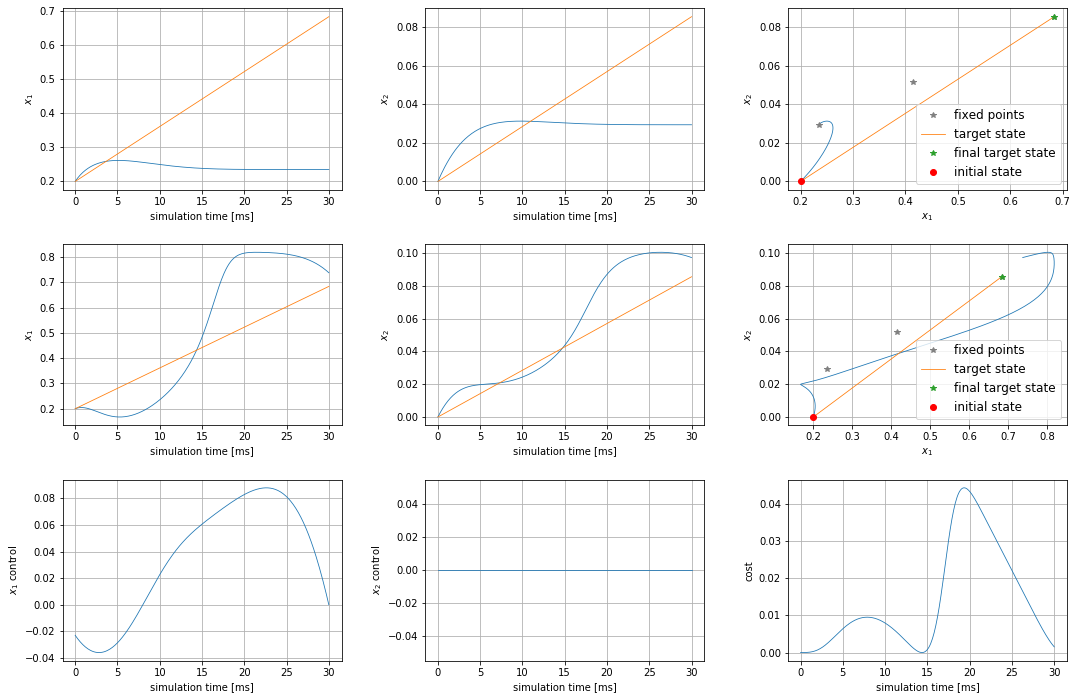

In [48]:
fhn.run()

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

#state_, target_state_, control_, u_mat_, u_scheme_, max_iteration_ = 100, tolerance_ = 1e-5, startStep_ = 10.,
#test_step_ = 1e-8, cntrl_max_ = 20., CGVar = None

optC, opt_state, cost, time = fhn.u_opt(state, target_state, control0, c_scheme, u_mat, u_scheme, max_iteration_ = 30,
                                    tolerance_ = 1.e-4, startStep_ = 10000., test_step_ = 1e-8, cntrl_max_ = 20.,
                                    CGVar = "HS")
print("cost: ", cost)
print("time: ", time)
plot_control(target_state, optC, fhn.cost(opt_state, target_state, fhn.getZeroControl()))

RUN  0 , total integrated cost =  0.9325660886124562
RUN  1 , total integrated cost =  0.5084563613343598
gradient change min, max, mean :  -1.5867487636414803 0.0 -0.6287873249328126
beta min, max =  1.05600653760623 1.2881419020580664
descent condition min, max, mean =  -7.904249525532197 0.43359193275920643 -1.4462238675012458
test step size computation : ------ step size, cost1, cost0 :  1e-08 0.5084559260211606 0.5084563613343598
1e-08
RUN  2 , total integrated cost =  0.4381153844773654
gradient change min, max, mean :  -0.7892168761231906 0.7426608768319557 0.011748956107289214
beta min, max =  0.924241376065151 15.15172465539489
descent condition min, max, mean =  -2.6130926166544923 9.091925024899627 1.5914515837021788
test step size computation : ------ step size, cost1, cost0 :  1e-08 0.43811586350538756 0.4381153844773654
0.0
no descent direction
test step size computation : ------ step size, cost1, cost0 :  1e-08 0.4381153377970591 0.4381153844773654
RUN  3 , total integra

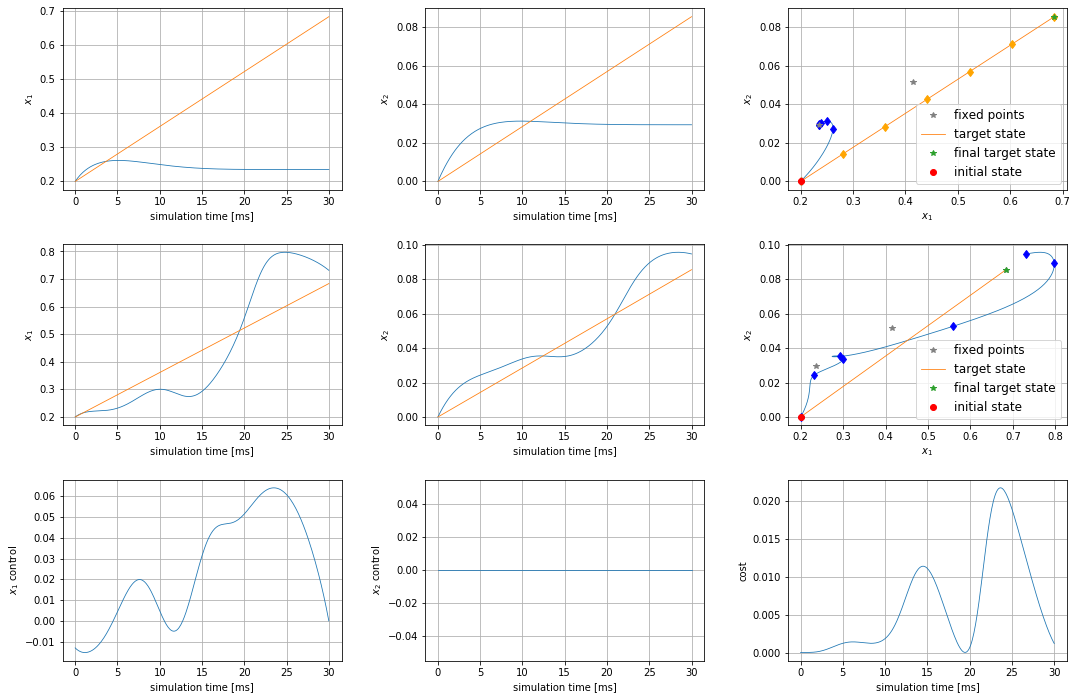

In [119]:
fhn.run()

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

#state_, target_state_, control_, u_mat_, u_scheme_, max_iteration_ = 100, tolerance_ = 1e-5, startStep_ = 10.,
#test_step_ = 1e-8, cntrl_max_ = 20., CGVar = None

optC, opt_state, cost, time = fhn.u_opt(state, target_state, control0, c_scheme, u_mat, u_scheme, max_iteration_ = 4,
                                    tolerance_ = 1.e-5, startStep_ = 10., test_step_ = 1e-8, cntrl_max_ = 20.,
                                    CGVar = "FR")
print("cost: ", cost)
print("time: ", time)
plot_control(target_state, optC, fhn.cost(opt_state, target_state, fhn.getZeroControl()))

RUN  0 , total integrated cost =  0.9325660886124562
RUN  1 , total integrated cost =  0.7498397269657994
gradient change min, max, mean :  0.0 3.2980499195019863 1.5241381862376335
beta min, max =  0.0 0.0
descent min, max, mean =  -5.183083686911872 0.0 -2.3547611002162374
RUN  2 , total integrated cost =  0.09102272486570802
gradient change min, max, mean :  -0.03739437406073271 5.121845537538357 2.177871982371914
beta min, max =  0.0 0.0
descent min, max, mean =  -10.503147845069806 0.0 -3.952649507380625
RUN  3 , total integrated cost =  0.05279785276843542
gradient change min, max, mean :  -3.266636757467789 0.003578149122087959 -1.3019909130617537
beta min, max =  0.0 0.0
descent min, max, mean =  -1.0210026641997725 0.0 -0.43883298044870145
RUN  4 , total integrated cost =  0.04391133931655834
gradient change min, max, mean :  -0.22423613134959997 0.21303158166769706 0.007654023072231314
beta min, max =  0.0 0.0
descent min, max, mean =  -0.11920250791128767 0.0 -0.044172983732

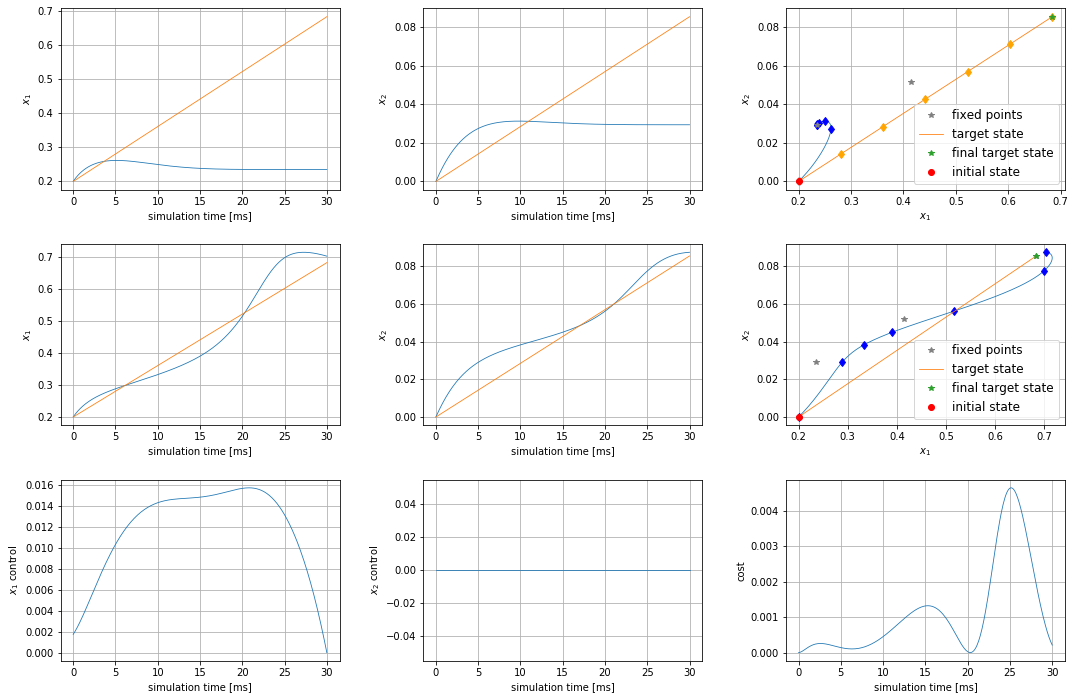

In [106]:
fhn.run()

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

#state_, target_state_, control_, u_mat_, u_scheme_, max_iteration_ = 100, tolerance_ = 1e-5, startStep_ = 10.,
#test_step_ = 1e-8, cntrl_max_ = 20., CGVar = None

optC, opt_state, cost, time = fhn.u_opt(state, target_state, control0, c_scheme, u_mat, u_scheme, max_iteration_ = 9,
                                    tolerance_ = 1.e-4, startStep_ = 0.005, test_step_ = 1e-8, cntrl_max_ = 20.,
                                    CGVar = None)
print("cost: ", cost)
print("time: ", time)
plot_control(target_state, optC, fhn.cost(opt_state, target_state, fhn.getZeroControl()))

In [104]:
# plot uncontrolled dynamics, controlled dynamics
def plot_control(target_, control_, cost_):
    
    # no control
    fhn.run()

    fig, ax = plt.subplots(3, 3, figsize=(18, 12))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

    ax[0,0].plot(fhn.t, fhn.x[0,:])
    ax[0,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[0,0].set(xlabel='simulation time [ms]', ylabel='$x_1$')
    ax[0,1].plot(fhn.t, fhn.y[0,:])
    ax[0,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[0,1].set(xlabel='simulation time [ms]', ylabel='$x_2$')
    ax[0,2].plot(fhn.x[0,:], fhn.y[0,:])
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[0,2].plot(fhn.x[0,i], fhn.y[0,i], c="blue", marker="d")
    ax[0,2].plot(fixed_points[:,0], fixed_points[:,1], '*', c='grey', label='fixed points')
    ax[0,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[0,2].plot(target_[0,0,i], target_[0,1,i], c="orange", marker="d")
    ax[0,2].plot(target_[0,0,-1], target_[0,1,-1], '*', linewidth = 1, label="final target state")
    ax[0,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', c='red', label="initial state")
    ax[0,2].legend()
    ax[0,2].set(xlabel='$x_1$', ylabel='$x_2$')

    fhn.run(control=control_)

    ax[1,0].plot(fhn.t, fhn.x[0,:], label="$x_1$")
    ax[1,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[1,0].set(xlabel='simulation time [ms]', ylabel='$x_1$')
    ax[1,1].plot(fhn.t, fhn.y[0,:], label="$x_2$")
    ax[1,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[1,1].set(xlabel='simulation time [ms]', ylabel='$x_2$')
    ax[1,2].plot(fhn.x[0,:], fhn.y[0,:])
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[1,2].plot(fhn.x[0,i], fhn.y[0,i], c="blue", marker="d")
    ax[1,2].plot(fixed_points[:,0], fixed_points[:,1], '*', c='grey', label='fixed points')
    ax[1,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    ax[1,2].plot(target_[0,0,-1], target_[0,1,-1], '*', linewidth = 1, label="final target state")
    ax[1,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', c='red', label="initial state")
    ax[1,2].legend()
    ax[1,2].set(xlabel='$x_1$', ylabel='$x_2$')
    
    ax[2,0].plot(fhn.t, control_[0,0,:])
    ax[2,0].set(xlabel='simulation time [ms]', ylabel='$x_1$ control')
    #ax[2,0].set_ylim(-0.1, 0.1)
    ax[2,1].plot(fhn.t, control_[0,1,:])
    ax[2,1].set(xlabel='simulation time [ms]', ylabel='$x_2$ control')
    ax[2,2].plot(fhn.t, cost_)
    ax[2,2].set(xlabel='simulation time [ms]', ylabel='cost')
    
    #plt.savefig('control.png')